In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv("Futurology.csv")

# Show first rows
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.368081e+09,3111,i.imgur.com,1dzk9l,Pardon me future... go right ahead.,ilovepixar,7391,4280,858,http://www.reddit.com/r/Futurology/comments/1d...,NaN,NaN,False,http://c.thumbs.redditmedia.com/GDYvka3Ms9mpI-...,t5_2t7no,False,NaN,NaN,False,t3_1dzk9l,http://i.imgur.com/XUbs4OM.jpg,NaN
1,1.347846e+09,2997,i.imgur.com,10014m,Just made this. Maybe one day this will be our...,LogicaRex,4439,1442,299,http://www.reddit.com/r/Futurology/comments/10...,NaN,NaN,False,http://f.thumbs.redditmedia.com/gYIsaPYYdAqJqp...,t5_2t7no,False,NaN,NaN,False,t3_10014m,http://i.imgur.com/Yk7i7.jpg,NaN
2,1.375982e+09,2887,cdn.theatlantic.com,1jysrc,Who would have thought that could be possible ...,SergeCalame,6093,3206,392,http://www.reddit.com/r/Futurology/comments/1j...,NaN,NaN,False,http://c.thumbs.redditmedia.com/H37E9othP4ydby...,t5_2t7no,False,NaN,NaN,False,t3_1jysrc,http://cdn.theatlantic.com/static/infocus/shan...,NaN
3,1.375280e+09,2564,i.imgur.com,1jf6p5,What if? Make your shout out,Xenophon1,5378,2814,348,http://www.reddit.com/r/Futurology/comments/1j...,NaN,NaN,False,default,t5_2t7no,False,NaN,NaN,False,t3_1jf6p5,http://i.imgur.com/Ysmlg.png,NaN
4,1.364414e+09,2488,indiegogo.com,1b4oid,NASA is looking to place an ad in front of the...,Alonsonater,3930,1442,128,http://www.reddit.com/r/Futurology/comments/1b...,NaN,NaN,False,default,t5_2t7no,False,NaN,NaN,False,t3_1b4oid,http://www.indiegogo.com/projects/we-are-the-e...,NaN


In [3]:
# Dataset info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  979 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                67 non-null     str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      21
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   933
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class    1000
is_self                      0
name                         0
url                          0
distinguished              989
dtype: int64

In [5]:
print(df.select_dtypes(exclude=['number']).columns)

Index(['domain', 'id', 'title', 'author', 'permalink', 'selftext', 'over_18',
       'thumbnail', 'subreddit_id', 'edited', 'is_self', 'name', 'url',
       'distinguished'],
      dtype='str')


In [8]:
df.columns

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')

In [12]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')


In [20]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [31]:
df.columns

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')

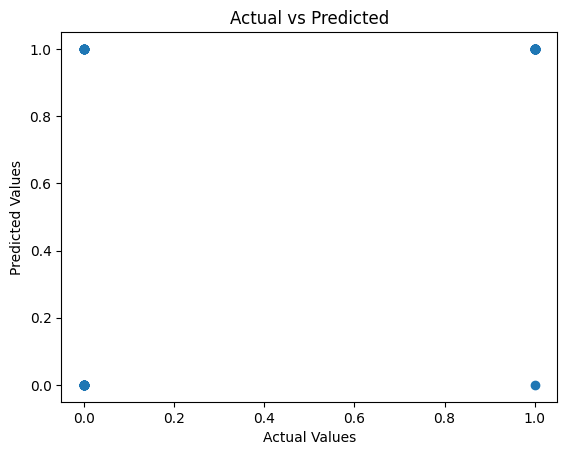

In [33]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()